In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import matplotlib.pyplot as plt
import tifffile
import numpy as np

DAPI_PATH = '/data1/peerd/moormana/data/segger/xenium_andrew_cornish/output-XETG00174__0065675__Region_2__20250509__190739/data/raw/xenium/morphology_focus/morphology_focus_0000.ome.tif'
dapi = tifffile.imread(
    DAPI_PATH
)

dapi.shape

(30703, 39824)

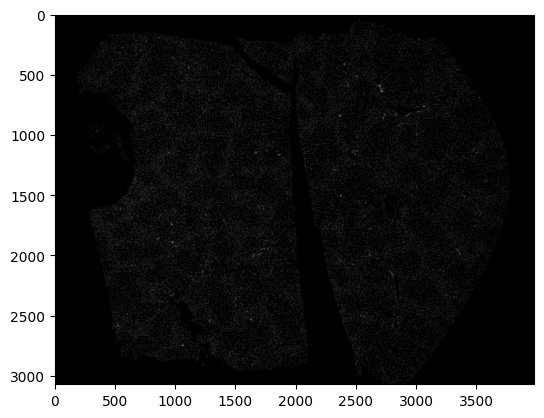

In [8]:
plt.imshow(dapi[::10, ::10], cmap = "gray")

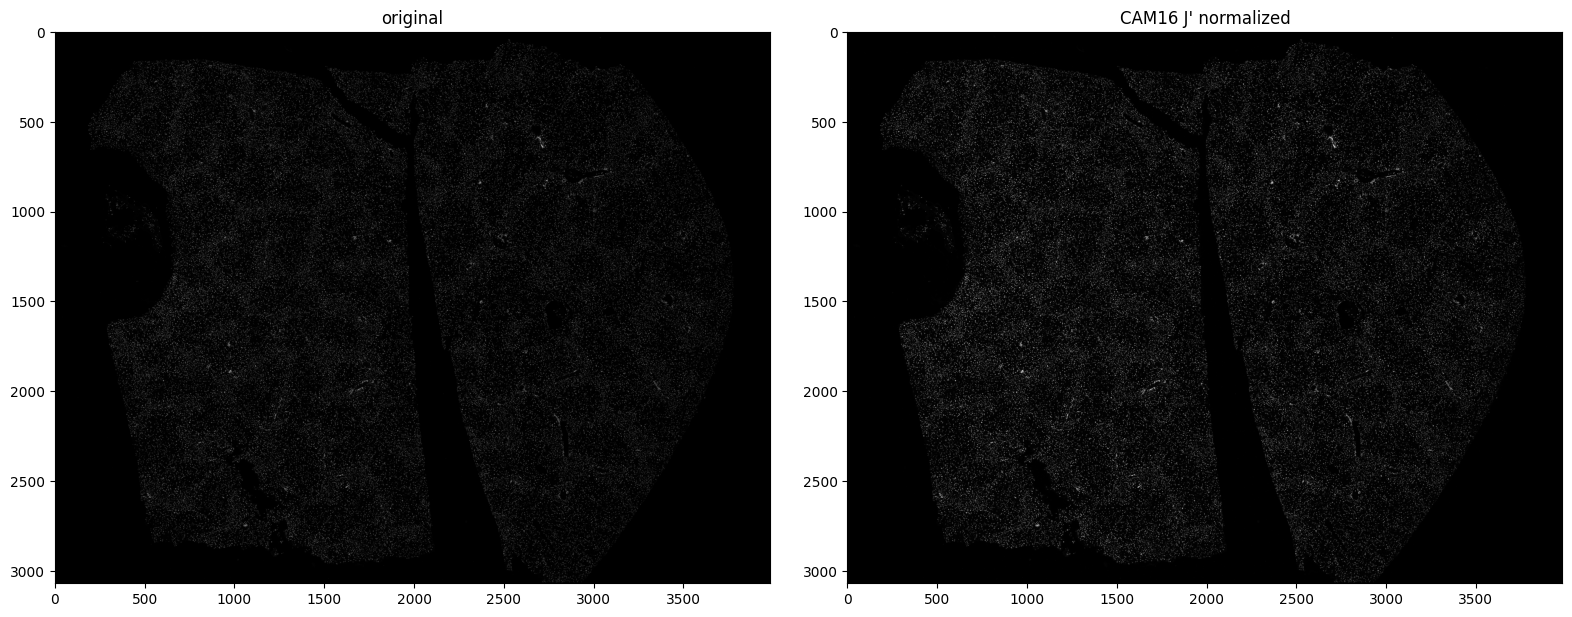

In [10]:
import numpy as np
import torch

# ── CAM16 constants (average surround, LA=20, Yw=100) ───────────────────────
_M1 = torch.tensor([
    [0.4124564, 0.3575761, 0.1804375],
    [0.2126729, 0.7151522, 0.0721750],
    [0.0193339, 0.1191920, 0.9503041],
], dtype=torch.float32)

_M2 = torch.tensor([
    [ 0.401288,  0.650173, -0.051461],
    [-0.250268,  1.204414,  0.045854],
    [-0.002079,  0.048952,  0.953127],
], dtype=torch.float32)

_LA  = 20.0
_k   = 1.0 / (5 * _LA + 1)
_FL  = float(0.2 * _k**4 * (5*_LA) + 0.1 * (1 - _k**4)**2 * (5*_LA)**(1/3))
_c   = 0.69
_z   = 1.48 + 1.0   # n=1 for Yw=100
_Nbb = 0.725
_cJ  = 0.007

# D65 white → LMS (precomputed, shape (3,))
_D65_XYZ = torch.tensor([0.95047, 1.00000, 1.08883], dtype=torch.float32)


def _lms_white(dev):
    d65 = _D65_XYZ.to(dev) * 100.0          # (3,)
    lms_w = _M2.to(dev) @ (_M1.to(dev) @ d65)  # (3,)  XYZ→LMS via M2@M1@xyz
    return lms_w                              # adapt factor = 100/lms_w


def _process_tile(tile_np: np.ndarray, lms_w: torch.Tensor, adapt: torch.Tensor, dev: torch.device) -> np.ndarray:
    """tile_np: (th, tw) float32 in [0,1]. Returns (th, tw) float32 J'."""
    th, tw = tile_np.shape
    M1 = _M1.to(dev)
    M2 = _M2.to(dev)

    # (th*tw,) → no RGB stack, treat grayscale as neutral: Y channel only
    # For neutral gray R=G=B=v: XYZ = v * sum_of_columns = v * [0.950, 1.000, 1.089]
    # But we still need 3 channels for LMS. Use the Y row shortcut:
    # xyz = v * D65_XYZ  (since neutral sRGB maps to the white point scaled by v)
    flat = torch.from_numpy(tile_np.ravel()).to(dev)  # (N,)

    # linearize sRGB gamma
    lin = torch.where(flat <= 0.04045, flat / 12.92, ((flat + 0.055) / 1.055).pow(2.4))

    # neutral gray: xyz = lin * D65_XYZ (scaled to Y=100)
    # lms = M2 @ (M1 @ xyz) = lin * lms_w  (since lms_w = M2 @ M1 @ D65*100)
    lms_c = lin.unsqueeze(1) * lms_w.unsqueeze(0) * adapt.unsqueeze(0)  # (N, 3)

    # nonlinear compression  p = 400*(FL*t/100)^0.42 / ((FL*t/100)^0.42 + 27.13) + 0.1
    t = (_FL / 100.0) * lms_c.clamp(min=0)
    p = t.pow(0.42)
    lms_p = 400.0 * p / (p + 27.13) + 0.1   # (N, 3)

    # white point compressed (scalar per channel)
    t_w = (_FL / 100.0) * (lms_w * adapt).clamp(min=0)
    p_w = t_w.pow(0.42)
    lms_pw = 400.0 * p_w / (p_w + 27.13) + 0.1  # (3,)

    Aw = (2*lms_pw[0] + lms_pw[1] + 0.05*lms_pw[2] - 0.305) * _Nbb
    A  = (2*lms_p[:,0] + lms_p[:,1] + 0.05*lms_p[:,2] - 0.305) * _Nbb

    J  = 100.0 * (A / Aw).clamp(min=0).pow(_c * _z)
    Jp = (1 + 100*_cJ) * J / (1 + _cJ * J)

    return Jp.cpu().numpy().reshape(th, tw)


def cam16_Jprime(img_gray: np.ndarray, tile_size: int = 2048, device: str = "cuda") -> np.ndarray:
    """
    img_gray  : (H, W) any dtype, raw pixels
    tile_size : pixels per tile side — tune to fit GPU VRAM
    Returns   : (H, W) float32 in [0, 1]
    """
    dev = torch.device(device if torch.cuda.is_available() else "cpu")

    # robust percentile clip → [0, 1]
    lo = float(np.percentile(img_gray, 0.1))
    hi = float(np.percentile(img_gray, 99.9))
    img_f = np.clip((img_gray.astype(np.float32) - lo) / (hi - lo + 1e-6), 0, 1)

    # precompute white point once
    lms_w = _lms_white(dev)       # (3,)
    adapt = 100.0 / lms_w         # (3,)  D=1 full adaptation

    H, W = img_f.shape
    out = np.empty((H, W), dtype=np.float32)

    with torch.no_grad():
        for r in range(0, H, tile_size):
            for c in range(0, W, tile_size):
                tile = img_f[r:r+tile_size, c:c+tile_size]
                out[r:r+tile_size, c:c+tile_size] = _process_tile(tile, lms_w, adapt, dev)

    # global stretch of J' output
    out -= out.min()
    out /= (out.max() + 1e-6)
    return out


result = cam16_Jprime(dapi, tile_size=2048)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(dapi[::10, ::10], cmap="gray")
axes[0].set_title("original")
axes[1].imshow(result[::10, ::10], cmap="gray")
axes[1].set_title("CAM16 J' normalized")
plt.tight_layout()


In [11]:
import cv2

def normalize_cv2_fast(img, quantiles=[0.001, 0.99], clip_limit=1.0, grid_size=(20, 20)):
    lo, hi = np.quantile(img, quantiles)
    img = np.clip(img, lo, hi)
    if hi - lo < 1e-6:
        return np.zeros_like(img, dtype=np.float32)
    img_norm = ((img - lo) / (hi - lo) * 255).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    return clahe.apply(img_norm).astype(np.float32) / 255.0

dapi_norm_fast = normalize_cv2_fast(dapi)

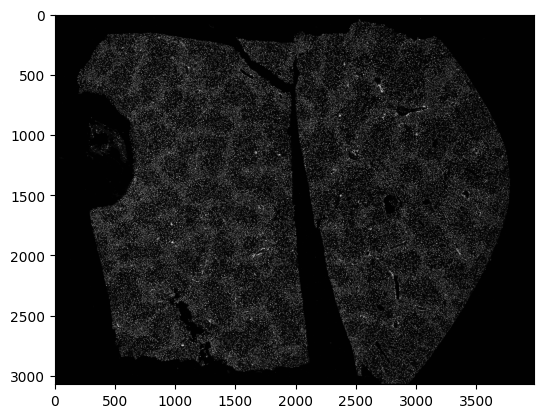

: 

In [ ]:
plt.imshow(dapi_norm_fast[::10, ::10], cmap = "gray")

In [ ]:
# import colour
# import numpy as np

# # 1. Normalize your DAPI array to 0-1 range
# # This is crucial for the sRGB conversion step
# dapi_min, dapi_max = dapi.min(), dapi.max()
# dapi_norm = (dapi - dapi_min) / (dapi_max - dapi_min)

# # 2. Map grayscale to "DAPI Blue" RGB
# # We create an (M, N, 3) array where:
# # Red = 0, Green = 0, Blue = dapi_norm
# rgb_grayscale = np.stack([dapi_norm, dapi_norm, dapi_norm], axis=-1)

# # 3. Convert sRGB to XYZ
# # colour-science handles the array broadcasting automatically
# xyz = colour.sRGB_to_XYZ(rgb_grayscale)

# # 4. Convert XYZ to CAM16-UCS
# # This returns J' (lightness), a' (red-green), b' (yellow-blue)
# jpapbp_dapi = colour.XYZ_to_CAM16UCS(xyz)

# print(f"Original shape: {dapi.shape}")
# print(f"CAM16-UCS shape: {jpapbp_dapi.shape}")